# Collecte des données
**Sources :** OpenMeteo (météo horaire) + yfinance (finance)

In [29]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import yfinance as yf
import httpx
import yaml

In [ ]:
# chargement de congiguration file le fichier de configuration pour éviter de hardcoder les paramètres dans le code

with open('../configs/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
print(f"Période : {cfg['data']['start_date']} -> {cfg['data']['end_date']}")
print(f"Localisation : {cfg['openmeteo']['latitude']}°N, {cfg['openmeteo']['longitude']}°E, Paris")
print(f"Variables météo : {cfg['openmeteo']['variables']}")

Période : 2018-01-01 -> 2024-12-31
Localisation : 48.8566°N, 2.3522°E, Paris
Variables météo : ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'surface_pressure', 'shortwave_radiation', 'cloudcover', 'et0_fao_evapotranspiration']


# Collect OpenMeteo
API historique publique — https://open-meteo.com/en/docs/historical-weather-api

In [25]:
om = cfg['openmeteo']

url   = om.get("base_url", "https://archive-api.open-meteo.com/v1/archive")

start = datetime.strptime(cfg["data"]["start_date"], "%Y-%m-%d")
end   = datetime.strptime(cfg["data"]["end_date"], "%Y-%m-%d")

data_brute = []

current = start
while current <= end:
    year_end = min(datetime(current.year, 12, 31), end)
    params = {
        "latitude":   om["latitude"],
        "longitude":  om["longitude"],
        "start_date": cfg["data"]["start_date"],
        "end_date":   cfg["data"]["end_date"],
        "hourly":     om["variables"],
        "timezone":   om.get("timezone", "Europe/Paris"),
        "wind_speed_unit": "ms",         # m/s (plus précis que km/h)
        "precipitation_unit": "mm",
    }
    params["start_date"] = current.strftime("%Y-%m-%d")
    params["end_date"]   = year_end.strftime("%Y-%m-%d")

    # récupère les data météo pour les dates spécifiées
    try:
        with httpx.Client(timeout=om.get("timeout_seconds", 60)) as client:
            resp = client.get(url, params=params)
            resp.raise_for_status()
            data = resp.json()

            print(data)

            hourly = data.get("hourly", {})
            if not hourly:
                raise ValueError(f"Réponse vide pour {params['start_date']}")

            df_year = pd.DataFrame(hourly)
            df_year["time"] = pd.to_datetime(df_year["time"])
            df_year = df_year.set_index("time").rename_axis("datetime")
            df_year.columns = [f"meteo_{c}" for c in df_year.columns]

            data_brute.append(df_year)
            break
    
    except httpx.HTTPError as e:
        print(f"HTTP error: {e}")

    current = datetime(current.year + 1, 1, 1)

df_meteo = pd.concat(data_brute) # concatène les dataframes annuels en un seul dataframe global

{'latitude': 48.89279, 'longitude': 2.2920206, 'generationtime_ms': 31.380891799926758, 'utc_offset_seconds': 3600, 'timezone': 'Europe/Paris', 'timezone_abbreviation': 'GMT+1', 'elevation': 36.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'm/s', 'precipitation': 'mm', 'surface_pressure': 'hPa', 'shortwave_radiation': 'W/m²', 'cloudcover': '%', 'et0_fao_evapotranspiration': 'mm'}, 'hourly': {'time': ['2018-01-01T00:00', '2018-01-01T01:00', '2018-01-01T02:00', '2018-01-01T03:00', '2018-01-01T04:00', '2018-01-01T05:00', '2018-01-01T06:00', '2018-01-01T07:00', '2018-01-01T08:00', '2018-01-01T09:00', '2018-01-01T10:00', '2018-01-01T11:00', '2018-01-01T12:00', '2018-01-01T13:00', '2018-01-01T14:00', '2018-01-01T15:00', '2018-01-01T16:00', '2018-01-01T17:00', '2018-01-01T18:00', '2018-01-01T19:00', '2018-01-01T20:00', '2018-01-01T21:00', '2018-01-01T22:00', '2018-01-01T23:00', '2018-01-02T00:00', '2018-01-02T01:00', '2018-01-02T

In [27]:
df_meteo = df_meteo[~df_meteo.index.duplicated(keep="first")] # supprime les doublons éventuels (au cas où l'API aurait renvoyé des données redondantes)
df_meteo.head()

,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_precipitation,meteo_surface_pressure,meteo_shortwave_radiation,meteo_cloudcover,meteo_et0_fao_evapotranspiration
datetime,,,,,,,,
2018-01-01 00:00:00,8.1,69,8.61,0.0,1002.2,0.0,2,0.06
2018-01-01 01:00:00,8.1,69,8.20,0.0,1002.5,0.0,1,0.06
2018-01-01 02:00:00,7.8,68,8.23,0.0,1003.4,0.0,59,0.06
2018-01-01 03:00:00,7.9,64,8.23,0.0,1004.2,0.0,54,0.07
2018-01-01 04:00:00,7.8,64,7.69,0.0,1004.7,0.0,44,0.06


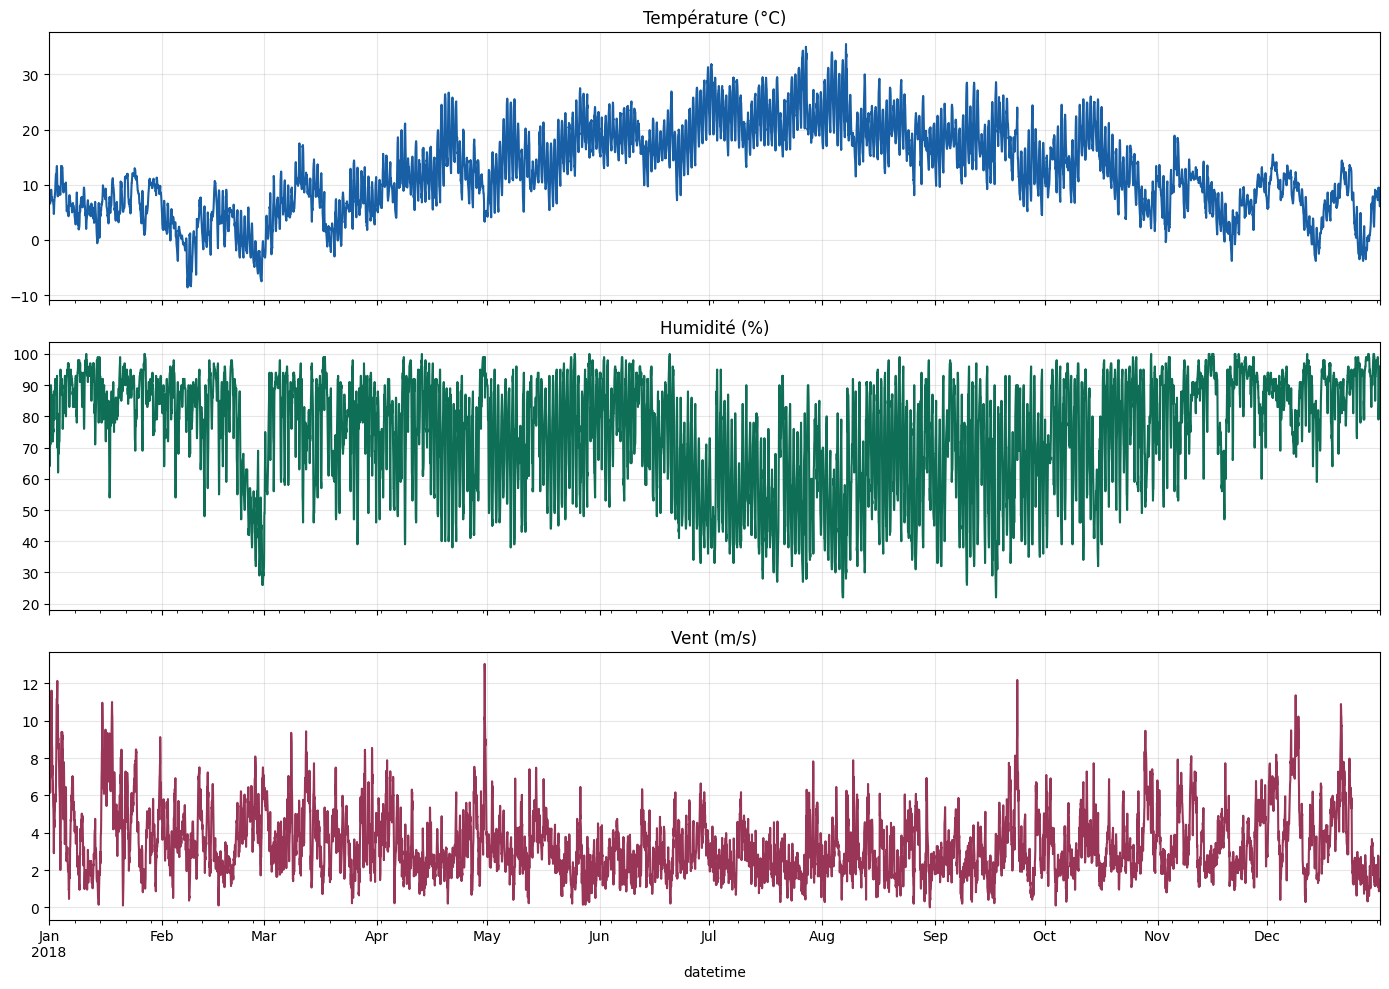

Météo visualisée


In [28]:
# Visualisation rapide
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df_meteo['meteo_temperature_2m'].plot(ax=axes[0], title='Température (°C)', color='#185FA5')
df_meteo['meteo_relative_humidity_2m'].plot(ax=axes[1], title='Humidité (%)', color='#0F6E56')
df_meteo['meteo_wind_speed_10m'].plot(ax=axes[2], title='Vent (m/s)', color='#993556')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/raw_weather_overview.png', dpi=150)
plt.show()
print('Météo visualisée')

# collect yfinance

In [45]:
tickers  = cfg["yfinance"]["tickers"]
start    = cfg["data"]["start_date"]
end      = cfg["data"]["end_date"]
interval = cfg["yfinance"].get("interval", "1d")

data_brute = []
for ticker in tickers:
    try:
        raw = yf.download(
            ticker,
            start=start,
            end=end,
            interval=interval,
            progress=False,
            timeout=30,
        )
    
        if isinstance(raw.columns, pd.MultiIndex):
            # mutipleindex
            raw.columns = raw.columns.droplevel(1)
        
        print(ticker)
        prefix = ticker.replace("^", "").replace(".", "_").lower() # nettoie le nom du ticker pour éviter les caractères spéciaux
        raw.columns = [f"fin_{prefix}_{c.lower()}" for c in raw.columns] # renomme les colonnes pour les différencier des autres sources de données
        raw.index.name = "datetime"
        raw.index = pd.to_datetime(raw.index)

        raw = raw.resample("h").ffill(limit=24)  # forward fill pour les données manquantes (max 24h) car possible ça reste le même prix pendant une journée sans mouvement

        data_brute.append(raw)

    except Exception as e:
        print(f"Erreur lors du téléchargement de {ticker} : {e}")
        continue
        
df_fin = pd.concat(data_brute, axis=1)
df_fin.index.name = "datetime"
df_fin = df_fin.sort_index()
df_fin = df_fin[~df_fin.index.duplicated(keep="first")]

df_fin.head()

$EDF.PA: possibly delisted; no timezone found

1 Failed download:
['EDF.PA']: possibly delisted; no timezone found


^FCHI
EDF.PA
TTE.PA
^GSPC


,fin_fchi_close,fin_fchi_high,fin_fchi_low,fin_fchi_open,fin_fchi_volume,fin_edf_pa_adj close,fin_edf_pa_close,fin_edf_pa_high,fin_edf_pa_low,fin_edf_pa_open,...,fin_tte_pa_close,fin_tte_pa_high,fin_tte_pa_low,fin_tte_pa_open,fin_tte_pa_volume,fin_gspc_close,fin_gspc_high,fin_gspc_low,fin_gspc_open,fin_gspc_volume
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-02 00:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,NaN,NaN,NaN,NaN,NaN,...,28.356276,28.568669,28.223913,28.568669,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 01:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,NaN,NaN,NaN,NaN,NaN,...,28.356276,28.568669,28.223913,28.568669,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 02:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,NaN,NaN,NaN,NaN,NaN,...,28.356276,28.568669,28.223913,28.568669,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 03:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,NaN,NaN,NaN,NaN,NaN,...,28.356276,28.568669,28.223913,28.568669,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 04:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,NaN,NaN,NaN,NaN,NaN,...,28.356276,28.568669,28.223913,28.568669,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09


In [46]:
# Corrélation rapide météo / finance
close_cols = [c for c in df_fin.columns if 'close' in c]
df_daily = pd.concat([df_meteo['meteo_temperature_2m'], df_fin[close_cols]], axis=1).resample('D').mean()
corr = df_daily.corr()
print('Corrélations avec la température :')
print(corr['meteo_temperature_2m'].sort_values(ascending=False))

Corrélations avec la température :
meteo_temperature_2m    1.000000
fin_tte_pa_close        0.754449
fin_gspc_close          0.490173
fin_fchi_close          0.458418
fin_edf_pa_adj close         NaN
fin_edf_pa_close             NaN
Name: meteo_temperature_2m, dtype: float64


# Sauvegarde des données brutes

In [48]:
df_meteo.to_parquet('../data/raw/weather_raw.parquet', compression="snappy")
df_fin.to_parquet('../data/raw/finance_raw.parquet', compression="snappy")